# Word2Vec 

"*Dime con quien andas y te diré quién eres*" - [Francisco de Quevedo en el siglo XVI](https://significalogia.com/dime-con-quien-andas-y-te-dire-quien-eres-significado-y-origen-de-este-refran/)
                                
*Word2Vec* es una técnica de **Procesamiento del Lenguaje Natural** (*NLP*) utilizada para representar palabras como vectores (en un **espacio continuo**) de características numéricas de baja dimensión. Este método, desarrollado por un equipo de Google dirigido por Tomas Mikolov en 2013, ha revolucionado la forma en que se representan las palabras en el espacio vectorial, permitiendo que las máquinas comprendan y procesen el texto de una manera más eficiente y efectiva.

*Word2Vec* utiliza dos arquitecturas principales para aprender las representaciones de las palabras:

1. **CBOW** (Continuous Bag of Words): Predice una palabra objetivo basada en su contexto circundante. Es decir, toma las palabras del contexto y trata de predecir la palabra central.
1. **Skip-gram**: Predice el contexto de una palabra objetivo. Toma una palabra central y trata de predecir las palabras circundantes en el contexto.

Ambos métodos se basan en redes neuronales simples y generan vectores de palabras que capturan las **relaciones semánticas** entre ellas.

El supuesto más importante de *Word2Vec* es que 2 palabras que tienen un **contexto similar**, entonces deben tener un **significado similar**, por ende, una representación vectorial similar.

Por ejemplo, palabras como "*perro*", "*cachorro*", "*mascota*" suelen estar en contextos similares, por ende su representación vectorial en *Word2Vec* debe ser similar. Es posible llegar a este tipo de conclusiones, gracias a que *Word2Vec* captura las relaciones semánticas entre palabras en base a los patrones descubiertos en la co-ocurrencia  de palabras dado un corpus.

# Load data

In [1]:
import itertools as it
from gensim.models.word2vec import LineSentence

c:\Users\eduardo.moreno\AppData\Local\anaconda3\envs\env_nlp\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
trigram_sentences_filepath = r'..\..\..\data\ngrams\fb-groups\trigram_sentences_all.txt'

In [3]:
trigram_sentences = LineSentence(trigram_sentences_filepath)

Algunos mensajes preprocesados son:

In [4]:
for trigram_sentence in it.islice(trigram_sentences, 123, 128):
    print(' '.join(trigram_sentence))
    print('')

compartar conocimiento idea iniciativa proyecto mejorar vida america_latino_caribe silvicultura biodiversidad desarrollo agricola turismo ciudades sostenibles mitigacion frente cambio_climatico infraestructura energia desarrollo_sostenible mas suscribiendote blog bid sostenibilidad ciudad sostenible cambio_climatico politica salvaguardia ambiental transporte energia agua saneamiento mirar video youtube tema descarga publicacion suscribete curso banco interamericano desarrollo bid mejorar_calidad vida america_latino_caribe ayudar mejorar salud educacion infraestructura traves apoyo financiero tecnico pais reducir pobreza desigualdad objetivo alcanzar desarrollo_sostenible respetuoso clima

upecista 22 estudiante ciencia politica pais juan jose ramirez algarra dejar alto nombre unicesar competir estudiante universidad publica privado colombia continuo excelente actividad academico juan jose ramirez algarra estudiante 10deg semestre programa derecho universidad popular cesar codear estudi

# Word2Vec

## CBOW

In [5]:
import multiprocessing
from gensim.models import Word2Vec

In [6]:
cores = multiprocessing.cpu_count()
print(f"Number of cores available: {cores}")

Number of cores available: 16


Definir el modelo

In [7]:
%%time
if 1 == 1:
    # Definir modelo
    w2v_model = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )
    # Construir vocabulario
    w2v_model.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )
    # Entrenar el modelo
    w2v_model.train(
        trigram_sentences, 
        total_examples=w2v_model.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model.save(r"..\..\models\w2v\w2v-cbow-fb-groups.model")
else:
    w2v_model = Word2Vec.load(r"..\..\models\w2v\w2v-cbow-fb-groups.model")

CPU times: total: 57min 25s
Wall time: 4min 12s


Comportamiento

In [8]:
similar_words = w2v_model.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatico: 0.5150887370109558
climatica: 0.4153779447078705
cambio_climatico: 0.4048258662223816
atmosferico: 0.336371511220932
calentamiento: 0.31457754969596863
condicion_climatica: 0.30405521392822266
temperatura: 0.2996741831302643
climatologia: 0.29265350103378296
fenomeno_meteorologicos: 0.2812335193157196
meteorologica: 0.27293071150779724


In [9]:
w2v_model.wv.most_similar(positive=["cambio"])

[('cambiar', 0.49862441420555115),
 ('transformacion', 0.3693806529045105),
 ('modificar', 0.3516096770763397),
 ('alteracion', 0.34455087780952454),
 ('modificacion', 0.3389367163181305),
 ('variacion', 0.338289737701416),
 ('drastico', 0.3294333517551422),
 ('radical', 0.3142049312591553),
 ('comportamiento', 0.28944888710975647),
 ('abrupto', 0.28649207949638367)]

In [10]:
w2v_model.wv.most_similar(positive=["cambio_climatico"])

[('calentamiento_global', 0.6169968247413635),
 ('cambioclimatico', 0.4777890741825104),
 ('crisis_climatico', 0.4743868112564087),
 ('clima', 0.4048258662223816),
 ('climatico', 0.3940120041370392),
 ('emergencia_climatico', 0.3841892182826996),
 ('calentamiento', 0.36844977736473083),
 ('calentamientoglobal', 0.3253706395626068),
 ('climatica', 0.3218595087528229),
 ('desertificacion', 0.3119562566280365)]

In [11]:
w2v_model.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.5877925753593445),
 ('ambiente', 0.5069748759269714),
 ('cuidado_medio_ambiente', 0.37173938751220703),
 ('proteccion_medio_ambiente', 0.35203930735588074),
 ('ambiental', 0.3468584716320038),
 ('recurso_natural', 0.3407193422317505),
 ('medioambiental', 0.3217666745185852),
 ('biodiversidad', 0.31739550828933716),
 ('naturaleza', 0.3099958300590515),
 ('salud', 0.30701228976249695)]

In [12]:
w2v_model.wv.most_similar(positive=["agua"])

[('agua_potable', 0.5061607360839844),
 ('agua_dulce', 0.49455341696739197),
 ('acuifero', 0.41485628485679626),
 ('liquido', 0.39360228180885315),
 ('rio', 0.38480985164642334),
 ('nutrient', 0.36342257261276245),
 ('mar', 0.3605921268463135),
 ('recurso_hidrico', 0.35267242789268494),
 ('suelo', 0.3434363305568695),
 ('oceano', 0.3422759771347046)]

In [13]:
w2v_model.wv.most_similar(positive=["sol"])

[('luna', 0.38498571515083313),
 ('campo_magnetico', 0.3830108940601349),
 ('luz', 0.37531471252441406),
 ('solar', 0.37304922938346863),
 ('estrella', 0.35916197299957275),
 ('rayo', 0.35667383670806885),
 ('rayo_sol', 0.3329441249370575),
 ('luz_solar', 0.326029509305954),
 ('calor', 0.32413578033447266),
 ('cosmico', 0.31476861238479614)]

In [14]:
w2v_model.wv.most_similar(positive=["desastre"])

[('catastrofe', 0.4537365138530731),
 ('catastrof', 0.43768298625946045),
 ('desastre_natural', 0.39985522627830505),
 ('dano', 0.35210517048835754),
 ('cataclismo', 0.3408704698085785),
 ('inundacion', 0.3222508430480957),
 ('estudiar_comunicar', 0.311468243598938),
 ('creacion_gimir_dolor_parto', 0.3099031150341034),
 ('tragedia', 0.30028778314590454),
 ('calamidad', 0.3001764714717865)]

In [15]:
w2v_model.wv.most_similar(positive=["desastre_natural"])

[('catastrof', 0.4351348578929901),
 ('desastre', 0.3998551666736603),
 ('catastrof_natural', 0.34865784645080566),
 ('fenomeno_natural', 0.3410966396331787),
 ('terremoto', 0.34028229117393494),
 ('huracan', 0.33896487951278687),
 ('fenomeno_meteorologico_extremo', 0.331715852022171),
 ('inundacion', 0.32806986570358276),
 ('sequia', 0.31888827681541443),
 ('inundacion_sequia', 0.30605143308639526)]

In [16]:
w2v_model.wv.most_similar(positive=["incremento"])

[('aumento', 0.7287697196006775),
 ('aumentar', 0.5361970663070679),
 ('incrementar', 0.5128815174102783),
 ('disminucion', 0.4763137102127075),
 ('reduccion', 0.4676399827003479),
 ('aumento_temperatura', 0.39580008387565613),
 ('subida', 0.371900737285614),
 ('descenso', 0.34683161973953247),
 ('creciente', 0.33678945899009705),
 ('alza', 0.33547067642211914)]

In [17]:
w2v_model.wv.most_similar(positive=["temperatura"])

[('aumento_temperatura', 0.5924821496009827),
 ('grado_celsius', 0.5111657977104187),
 ('grado_centigrado', 0.508500874042511),
 ('calentamiento', 0.49005311727523804),
 ('deg_c', 0.473779559135437),
 ('calor', 0.4686170816421509),
 ('alto_temperatura', 0.46787065267562866),
 ('degc', 0.455452024936676),
 ('calido', 0.45501065254211426),
 ('precipitacion', 0.4523226320743561)]

In [18]:
w2v_model.wv.most_similar(positive=["bajar"])

[('subir', 0.48152655363082886),
 ('disminuir', 0.3455773591995239),
 ('descender', 0.33801546692848206),
 ('reducir', 0.3241983652114868),
 ('aumentar', 0.321809858083725),
 ('elevar', 0.31266188621520996),
 ('descenso', 0.29884859919548035),
 ('alto', 0.2970467209815979),
 ('estabilizar', 0.2816641926765442),
 ('ascender', 0.2693624198436737)]

In [19]:
w2v_model.wv.most_similar(positive=["mas"])

[('extremadamente', 0.3857153356075287),
 ('demasiado', 0.3822482228279114),
 ('relativamente', 0.33001255989074707),
 ('suficientemente', 0.3264944851398468),
 ('especialmente', 0.32146382331848145),
 ('particularmente', 0.3171083927154541),
 ('mundo', 0.3091685175895691),
 ('cuan', 0.2714765965938568),
 ('ano', 0.26838424801826477),
 ('volver', 0.2659823000431061)]

In [20]:
w2v_model.wv.most_similar(positive=["gobierno"])

[('ejecutivo', 0.39781591296195984),
 ('presidente', 0.38892751932144165),
 ('gobernante', 0.38636836409568787),
 ('autoridad', 0.37837737798690796),
 ('gobernar', 0.3509252071380615),
 ('administracion', 0.34265992045402527),
 ('partido', 0.34236666560173035),
 ('psoe', 0.33980146050453186),
 ('gubernamental', 0.32933130860328674),
 ('andres_manuel_lopez_obrador', 0.32709768414497375)]

Similitud entre 2 tokens:

In [21]:
w2v_model.wv.similarity("incrementar", "temperatura")

0.19603539

In [22]:
w2v_model.wv.similarity("disminuir", "temperatura")

0.26608357

## Skip Gram

In [23]:
%%time
if 1 == 1:
    w2v_model_sg = Word2Vec(
        min_count=200,
        window=3,
        #sample=6e-5, 
        alpha=0.05, 
        #min_alpha=0.0007, 
        #negative=20,
        vector_size=400,
        workers=cores-1,
        sg=1,
        seed=42,
    )

    w2v_model_sg.build_vocab(
        trigram_sentences, 
        progress_per=10000
    )

    w2v_model_sg.train(
        trigram_sentences, 
        total_examples=w2v_model_sg.corpus_count, 
        epochs=30, 
        report_delay=15
    )
    w2v_model_sg.save(r"..\..\models\w2v\w2v-sg-fb-groups.model")
else:
    w2v_model_sg = Word2Vec.load(r"..\..\models\w2v\w2v-sg-fb-groups.model")

CPU times: total: 1h 22s
Wall time: 4min 38s


In [24]:
similar_words = w2v_model_sg.wv.most_similar(positive=["clima"])
for word, similarity in similar_words:
    print(f"{word}: {similarity}")

climatico: 0.5132349133491516
climatica: 0.42825087904930115
cambio_climatico: 0.4000724256038666
atmosferico: 0.32427969574928284
temperatura: 0.31150341033935547
climatologia: 0.31149783730506897
fenomeno_meteorologicos: 0.2952166199684143
calentamiento: 0.2949516773223877
condicion_climatica: 0.2858855426311493
oceanica: 0.27374979853630066


In [25]:
w2v_model_sg.wv.most_similar(positive=["cambio"])

[('cambiar', 0.4861335754394531),
 ('transformacion', 0.38159608840942383),
 ('modificar', 0.342537522315979),
 ('alteracion', 0.34205296635627747),
 ('drastico', 0.33410122990608215),
 ('variacion', 0.3197886049747467),
 ('modificacion', 0.31392067670822144),
 ('radical', 0.30838462710380554),
 ('comportamiento', 0.2907254099845886),
 ('abrupto', 0.28945043683052063)]

In [26]:
w2v_model_sg.wv.most_similar(positive=["cambio_climatico"])

[('calentamiento_global', 0.596643328666687),
 ('crisis_climatico', 0.484407901763916),
 ('cambioclimatico', 0.4727029502391815),
 ('climatico', 0.4046053886413574),
 ('clima', 0.40007245540618896),
 ('emergencia_climatico', 0.3806832730770111),
 ('calentamiento', 0.34478825330734253),
 ('climatica', 0.3330140709877014),
 ('calentamientoglobal', 0.3211522698402405),
 ('perdida_biodiversidad', 0.30490541458129883)]

In [27]:
w2v_model_sg.wv.most_similar(positive=["medio_ambiente"])

[('medioambiente', 0.6017931699752808),
 ('ambiente', 0.5009430646896362),
 ('cuidado_medio_ambiente', 0.3581233620643616),
 ('ambiental', 0.3451859652996063),
 ('recurso_natural', 0.33867818117141724),
 ('proteccion_medio_ambiente', 0.3354857861995697),
 ('biodiversidad', 0.3302875757217407),
 ('ecologia', 0.32870718836784363),
 ('salud', 0.31357884407043457),
 ('naturaleza', 0.3008204996585846)]

In [28]:
w2v_model_sg.wv.most_similar(positive=["agua"])

[('agua_dulce', 0.5017093420028687),
 ('agua_potable', 0.49419716000556946),
 ('acuifero', 0.40694043040275574),
 ('rio', 0.39234331250190735),
 ('liquido', 0.38877561688423157),
 ('recurso_hidrico', 0.3631059527397156),
 ('nutrient', 0.3524162471294403),
 ('mar', 0.3515464663505554),
 ('beber', 0.3512318432331085),
 ('subterranea', 0.3399379849433899)]

In [29]:
w2v_model_sg.wv.most_similar(positive=["mas"])

[('demasiado', 0.3992744982242584),
 ('extremadamente', 0.3729955852031708),
 ('suficientemente', 0.3389197289943695),
 ('relativamente', 0.32039904594421387),
 ('particularmente', 0.3157232105731964),
 ('mar_cortare_impio_raere', 0.3055118918418884),
 ('especialmente', 0.3050485849380493),
 ('mundo', 0.3050084114074707),
 ('ave_cielo_pez', 0.29934021830558777),
 ('destruire_hombre_bestia_destruire', 0.29662203788757324)]

In [30]:
w2v_model_sg.wv.most_similar(positive=["ano"])

[('anos', 0.5461838245391846),
 ('mes', 0.5319956541061401),
 ('decada', 0.4520699083805084),
 ('anos_despues', 0.39875489473342896),
 ('periodo', 0.3942613899707794),
 ('siglo', 0.3738318979740143),
 ('dia', 0.3708188831806183),
 ('enero', 0.36658912897109985),
 ('2020', 0.36551377177238464),
 ('2016', 0.35525763034820557)]

In [31]:
w2v_model_sg.wv.most_similar(positive=["gobierno"])

[('gobernante', 0.4322046935558319),
 ('autoridad', 0.39175763726234436),
 ('presidente', 0.37805041670799255),
 ('ejecutivo', 0.3646675944328308),
 ('gobernar', 0.3585677146911621),
 ('gobernador', 0.3473224341869354),
 ('administracion', 0.34718531370162964),
 ('psoe', 0.33673766255378723),
 ('partido', 0.3352947533130646),
 ('gubernamental', 0.32934778928756714)]

# T-SNE

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [33]:
words = ["agua", "clima", "medio_ambiente", "paris", "cambio_climatico", "falta", "nube", "peligro", "recurso", "acuerdo", "america", "unido", "ley", "temperatura", "frio", "calor"]
print(f"Numero de palabras {len(words)}")
word_vectors = [w2v_model_sg.wv[word] for word in words]
word_vectors = np.array(word_vectors)

Numero de palabras 16


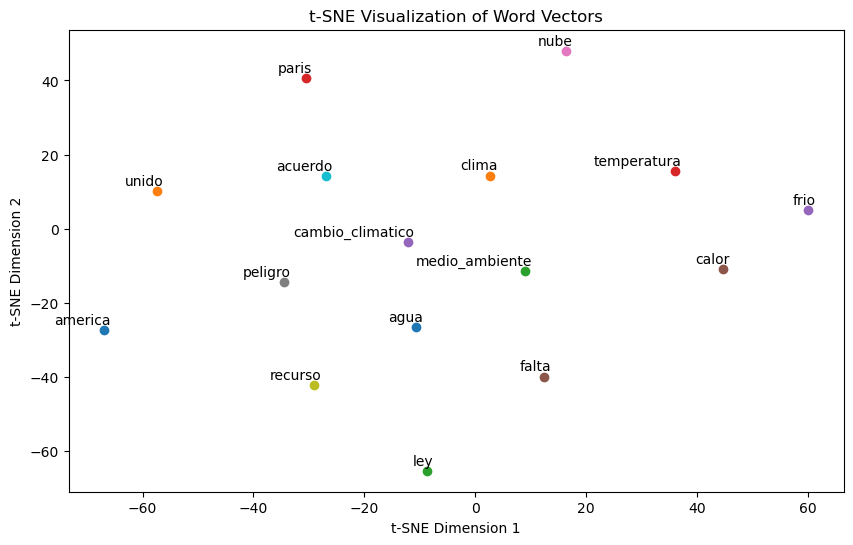

In [34]:
tsne_model = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_vectors = tsne_model.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(tsne_vectors[i, 0], tsne_vectors[i, 1])
    plt.annotate(word, xy=(tsne_vectors[i, 0], tsne_vectors[i, 1]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

plt.title('t-SNE Visualization of Word Vectors')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()